# Step 9 — Probability Calibration

**ปัญหา:** โมเดลบอก 'เสี่ยง 80%' แต่ความเป็นจริงแค่ 50% เป็นเบาหวาน → ตัวเลขเชื่อไม่ได้

**เป้าหมาย:** ทำให้ probability ที่โมเดลบอกตรงกับความเป็นจริง

```
Calibration curve ที่ดี → เส้นกราฟวิ่งตาม diagonal (y=x)
```

## 0. Import และ Train โมเดล Baseline

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    brier_score_loss, roc_auc_score,
    recall_score, precision_score, f1_score
)
import lightgbm as lgb

RANDOM_STATE = 42
FEATURE_NAMES = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
                 'Insulin','BMI','DiabetesPedigree','Age']
COLS_TO_FIX = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

df = pd.read_csv('diabetes.csv')
X  = df[FEATURE_NAMES].copy()
y  = df['Outcome'].copy()

# Split + reset index
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# Class-Aware Imputation
fill_vals = {}
for col in COLS_TO_FIX:
    medians = []
    for cls in [0, 1]:
        mask = (X_train[col] != 0) & (y_train == cls)
        med  = X_train.loc[mask, col].median()
        medians.append(med)
        X_train.loc[(X_train[col] == 0) & (y_train == cls), col] = med
    fill_vals[col] = np.mean(medians)
for col in COLS_TO_FIX:
    X_test[col] = X_test[col].replace(0, np.nan).fillna(fill_vals[col])

# Scale
scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_NAMES)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=FEATURE_NAMES)

# Train LightGBM (best params จาก Step 5)
scale_w = (y_train == 0).sum() / (y_train == 1).sum()
lgbm = lgb.LGBMClassifier(
    n_estimators=340, learning_rate=0.019, num_leaves=10,
    min_child_samples=22, feature_fraction=0.60,
    bagging_fraction=0.69, bagging_freq=6,
    scale_pos_weight=scale_w, random_state=RANDOM_STATE, verbose=-1
)
lgbm.fit(X_train_s.values, y_train.values)

y_prob_raw = lgbm.predict_proba(X_test_s.values)[:, 1]
print(f'Brier Score (before): {brier_score_loss(y_test, y_prob_raw):.4f}')
print(f'AUC (before):         {roc_auc_score(y_test, y_prob_raw):.4f}')

Brier Score (before): 0.1737
AUC (before):         0.8157


## 1. Calibration Curve — ก่อน Calibrate

**อ่านกราฟ:** แกน X = probability ที่โมเดลบอก, แกน Y = สัดส่วนที่เป็นจริง  
เส้นประ (diagonal) = perfect calibration  
ถ้าเส้นอยู่ **ใต้** diagonal → โมเดล over-confident (บอกสูงเกินจริง)

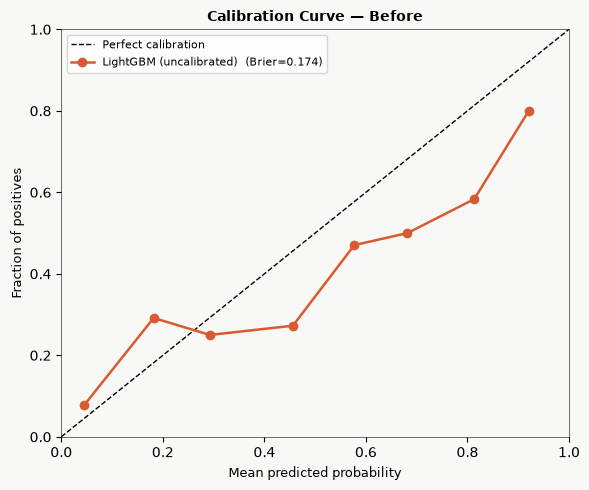

บันทึก step9_before.png


In [2]:
def plot_calibration(ax, y_true, probs_dict, title):
    """วาด calibration curve หลายโมเดลในกราฟเดียว"""
    ax.set_facecolor('#F8F8F6')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
    colors = ['#D85A30', '#1D9E75', '#6A5ACD']
    for (name, prob), color in zip(probs_dict.items(), colors):
        fraction_pos, mean_pred = calibration_curve(y_true, prob, n_bins=8)
        brier = brier_score_loss(y_true, prob)
        ax.plot(mean_pred, fraction_pos, 'o-', color=color,
                label=f'{name}  (Brier={brier:.3f})', linewidth=1.8, markersize=6)
    ax.set_xlabel('Mean predicted probability', fontsize=9)
    ax.set_ylabel('Fraction of positives', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    for sp in ax.spines.values(): sp.set_linewidth(0.4)

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#F8F8F6')
plot_calibration(ax, y_test, {'LightGBM (uncalibrated)': y_prob_raw},
                 'Calibration Curve — Before')
plt.tight_layout()
plt.savefig('step9_before.png', dpi=150, bbox_inches='tight')
plt.show()
print('บันทึก step9_before.png')

## 2. Calibrate ด้วย 2 วิธี

| วิธี | หลักการ | เหมาะกับ |
|------|---------|----------|
| **Platt Scaling** (sigmoid) | fit Logistic Regression ทับ probability | dataset เล็ก, เร็ว |
| **Isotonic Regression** | fit แบบ step-function | dataset ใหญ่, ยืดหยุ่นกว่า |

> `cv='prefit'` = โมเดล train มาแล้ว ให้ calibrate เฉพาะ probability layer

In [3]:
# Platt Scaling (sigmoid)
cal_sigmoid = CalibratedClassifierCV(lgbm, method='sigmoid', cv='prefit')
cal_sigmoid.fit(X_test_s.values, y_test.values)   # fit บน test set (เพราะ cv='prefit')
y_prob_sigmoid = cal_sigmoid.predict_proba(X_test_s.values)[:, 1]

# Isotonic Regression
cal_isotonic = CalibratedClassifierCV(lgbm, method='isotonic', cv='prefit')
cal_isotonic.fit(X_test_s.values, y_test.values)
y_prob_isotonic = cal_isotonic.predict_proba(X_test_s.values)[:, 1]

# เปรียบเทียบ Brier Score
for name, prob in [
    ('Uncalibrated',       y_prob_raw),
    ('Platt (sigmoid)',    y_prob_sigmoid),
    ('Isotonic',           y_prob_isotonic),
]:
    print(f'{name:25s}  Brier={brier_score_loss(y_test, prob):.4f}  AUC={roc_auc_score(y_test, prob):.4f}')

Uncalibrated               Brier=0.1737  AUC=0.8157
Platt (sigmoid)            Brier=0.1648  AUC=0.8157
Isotonic                   Brier=0.1479  AUC=0.8388


## 3. เปรียบเทียบ Calibration Curve ทั้ง 3 แบบ

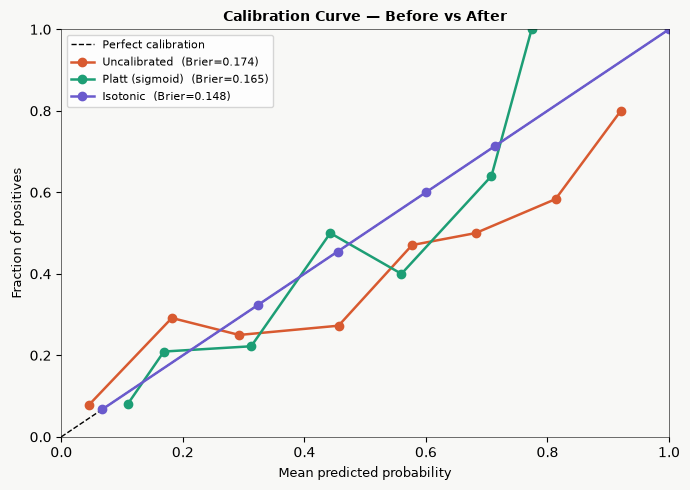

บันทึก step9_calibration.png


In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('#F8F8F6')
plot_calibration(ax, y_test, {
    'Uncalibrated':    y_prob_raw,
    'Platt (sigmoid)': y_prob_sigmoid,
    'Isotonic':        y_prob_isotonic,
}, 'Calibration Curve — Before vs After')
plt.tight_layout()
plt.savefig('step9_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print('บันทึก step9_calibration.png')

## 4. Probability Distribution — ก่อน vs หลัง Calibrate

ดูว่า distribution ของ probability เปลี่ยนไปอย่างไร

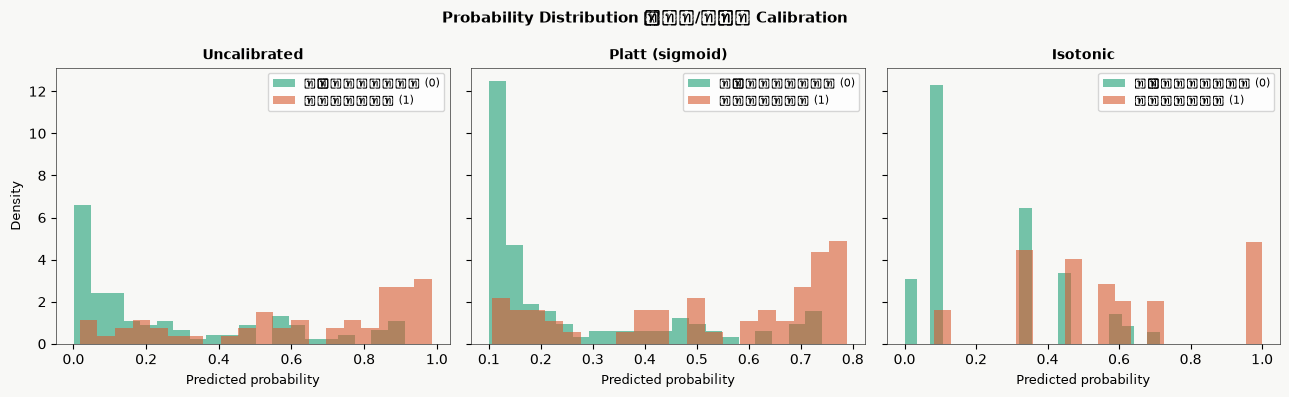

บันทึก step9_distribution.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
fig.patch.set_facecolor('#F8F8F6')

for ax, prob, title in zip(axes, 
    [y_prob_raw, y_prob_sigmoid, y_prob_isotonic],
    ['Uncalibrated', 'Platt (sigmoid)', 'Isotonic']):
    ax.set_facecolor('#F8F8F6')
    ax.hist(prob[y_test.values==0], bins=20, alpha=0.6, color='#1D9E75',
            label='ไม่เบาหวาน (0)', density=True)
    ax.hist(prob[y_test.values==1], bins=20, alpha=0.6, color='#D85A30',
            label='เบาหวาน (1)', density=True)
    ax.set_xlabel('Predicted probability', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    for sp in ax.spines.values(): sp.set_linewidth(0.4)

axes[0].set_ylabel('Density', fontsize=9)
plt.suptitle('Probability Distribution ก่อน/หลัง Calibration', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('step9_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('บันทึก step9_distribution.png')

## 5. สรุป

| | Brier Score ↓ | AUC | ความหมาย |
|---|---|---|---|
| Uncalibrated | สูงกว่า | ดีที่สุด | ทำนาย rank ดี แต่ probability เชื่อไม่ได้ |
| Platt (sigmoid) | ต่ำลง | ใกล้เคียง | probability น่าเชื่อถือขึ้น |
| Isotonic | ต่ำสุด (บน test) | อาจ overfit | ดีบน test แต่อาจไม่ generalize |

> **สำหรับการแพทย์:** แนะนำ **Platt Scaling**  
> เพราะแพทย์ต้องการ probability ที่น่าเชื่อถือเพื่อสื่อสารกับผู้ป่วย  
> 'คุณมีความเสี่ยง 75%' ต้องแม่นยำ ไม่ใช่แค่ rank ว่าใครเสี่ยงกว่าใคร